1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams["figure.figsize"] = (10, 6)
sns.set_style("whitegrid")

2. Load Dataset

In [2]:
file_path = "StudentPerformanceFactors.csv"
df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Dataset Shape: (6607, 20)

Columns:
 ['Hours_Studied', 'Attendance', 'Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Sleep_Hours', 'Previous_Scores', 'Motivation_Level', 'Internet_Access', 'Tutoring_Sessions', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Physical_Activity', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender', 'Exam_Score']


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


3. Inspect Data Types and Basic Info

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

4. Check Missing Values

In [4]:
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

print("\nTotal Missing Values:", df.isnull().sum().sum())

Parental_Education_Level    90
Teacher_Quality             78
Distance_from_Home          67
dtype: int64


Total Missing Values: 235


5. Check Duplicate Rows

In [5]:
duplicate_count = df.duplicated().sum()
print("Number of Duplicate Rows:", duplicate_count)

Number of Duplicate Rows: 0


6. Basic Cleaning

In [6]:
df = df.drop_duplicates().reset_index(drop=True)

df.columns = [col.strip() for col in df.columns]

print("Shape after basic cleaning:", df.shape)

Shape after basic cleaning: (6607, 20)


7. Target Variable Overview: Exam_Score

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


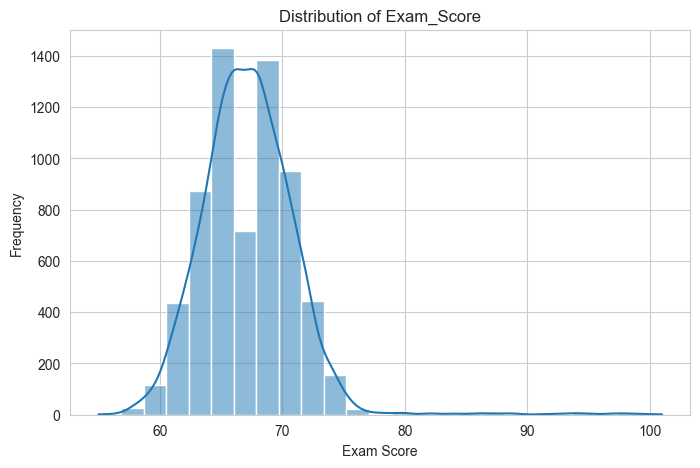

In [7]:
print(df["Exam_Score"].describe())

plt.figure(figsize=(8, 5))
sns.histplot(df["Exam_Score"], kde=True, bins=25)
plt.title("Distribution of Exam_Score")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")
plt.show()

8. Identify Key Variables for This Study

In [8]:
psychosocial_vars = [
    "Motivation_Level",
    "Peer_Influence",
    "Access_to_Resources"
]

academic_vars = [
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions"
]

print("Psychosocial Variables:", psychosocial_vars)
print("Academic Variables:", academic_vars)

Psychosocial Variables: ['Motivation_Level', 'Peer_Influence', 'Access_to_Resources']
Academic Variables: ['Hours_Studied', 'Attendance', 'Previous_Scores', 'Tutoring_Sessions']


9. Check Unique Values for Psychosocial Variables

In [9]:
for col in psychosocial_vars:
    print(f"\n{col}:")
    print(df[col].value_counts())


Motivation_Level:
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Peer_Influence:
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Access_to_Resources:
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64


10. Group-wise Mean Exam Score by Psychosocial Variables

In [10]:
for col in psychosocial_vars:
    print(f"\nMean Exam Score by {col}:")
    display(df.groupby(col)["Exam_Score"].mean().sort_values())


Mean Exam Score by Motivation_Level:


Motivation_Level
Low       66.752194
Medium    67.330648
High      67.704321
Name: Exam_Score, dtype: float64


Mean Exam Score by Peer_Influence:


Peer_Influence
Negative    66.564270
Neutral     67.197917
Positive    67.623199
Name: Exam_Score, dtype: float64


Mean Exam Score by Access_to_Resources:


Access_to_Resources
Low       66.203351
Medium    67.134378
High      68.092152
Name: Exam_Score, dtype: float64

11. Visualize Exam Score by Psychosocial Variables

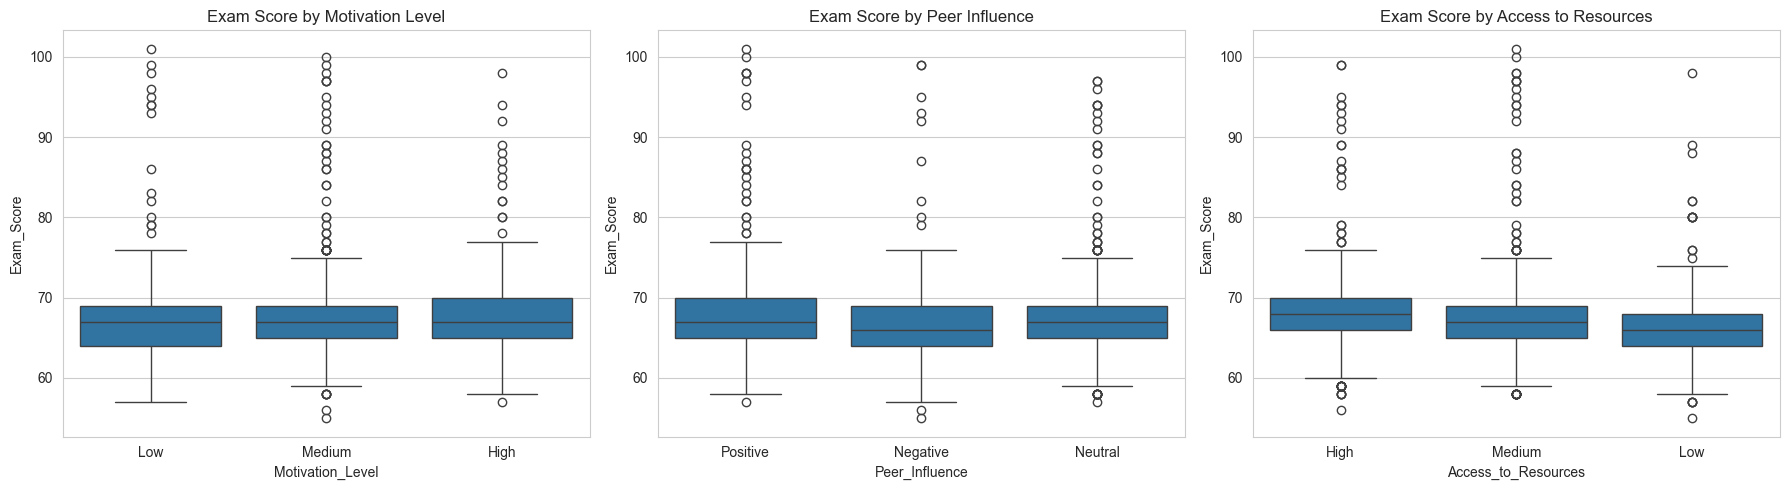

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.boxplot(data=df, x="Motivation_Level", y="Exam_Score", ax=axes[0])
axes[0].set_title("Exam Score by Motivation Level")

sns.boxplot(data=df, x="Peer_Influence", y="Exam_Score", ax=axes[1])
axes[1].set_title("Exam Score by Peer Influence")

sns.boxplot(data=df, x="Access_to_Resources", y="Exam_Score", ax=axes[2])
axes[2].set_title("Exam Score by Access to Resources")

plt.tight_layout()
plt.show()

12. Summary Statistics for Academic Variables

In [12]:
display(df[academic_vars].describe())

,Hours_Studied,Attendance,Previous_Scores,Tutoring_Sessions
count,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,75.070531,1.493719
std,5.990594,11.547475,14.399784,1.230570
min,1.000000,60.000000,50.000000,0.000000
25%,16.000000,70.000000,63.000000,1.000000
50%,20.000000,80.000000,75.000000,1.000000
75%,24.000000,90.000000,88.000000,2.000000
max,44.000000,100.000000,100.000000,8.000000


13. Correlation of Academic Variables with Exam Score

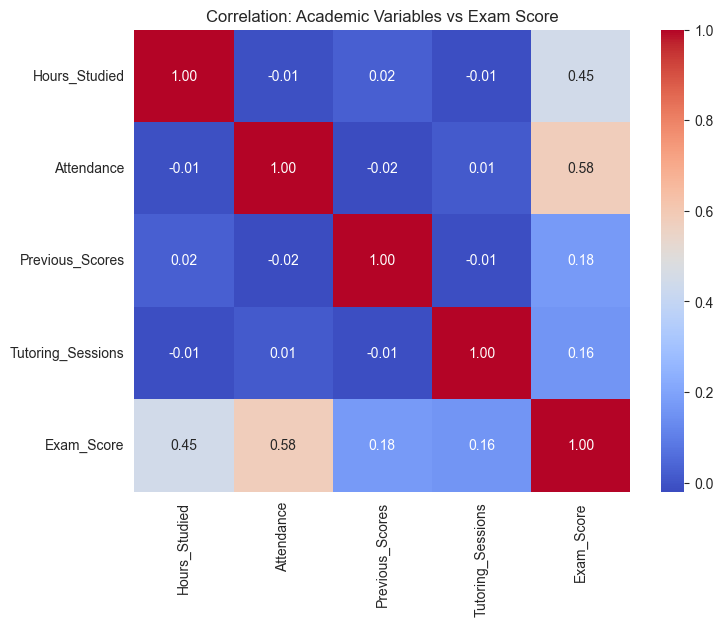


Correlation with Exam_Score:


Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Name: Exam_Score, dtype: float64

In [13]:
corr_cols = academic_vars + ["Exam_Score"]
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation: Academic Variables vs Exam Score")
plt.show()

print("\nCorrelation with Exam_Score:")
display(corr_matrix["Exam_Score"].sort_values(ascending=False))

14. Scatterplots for Key Academic Predictors

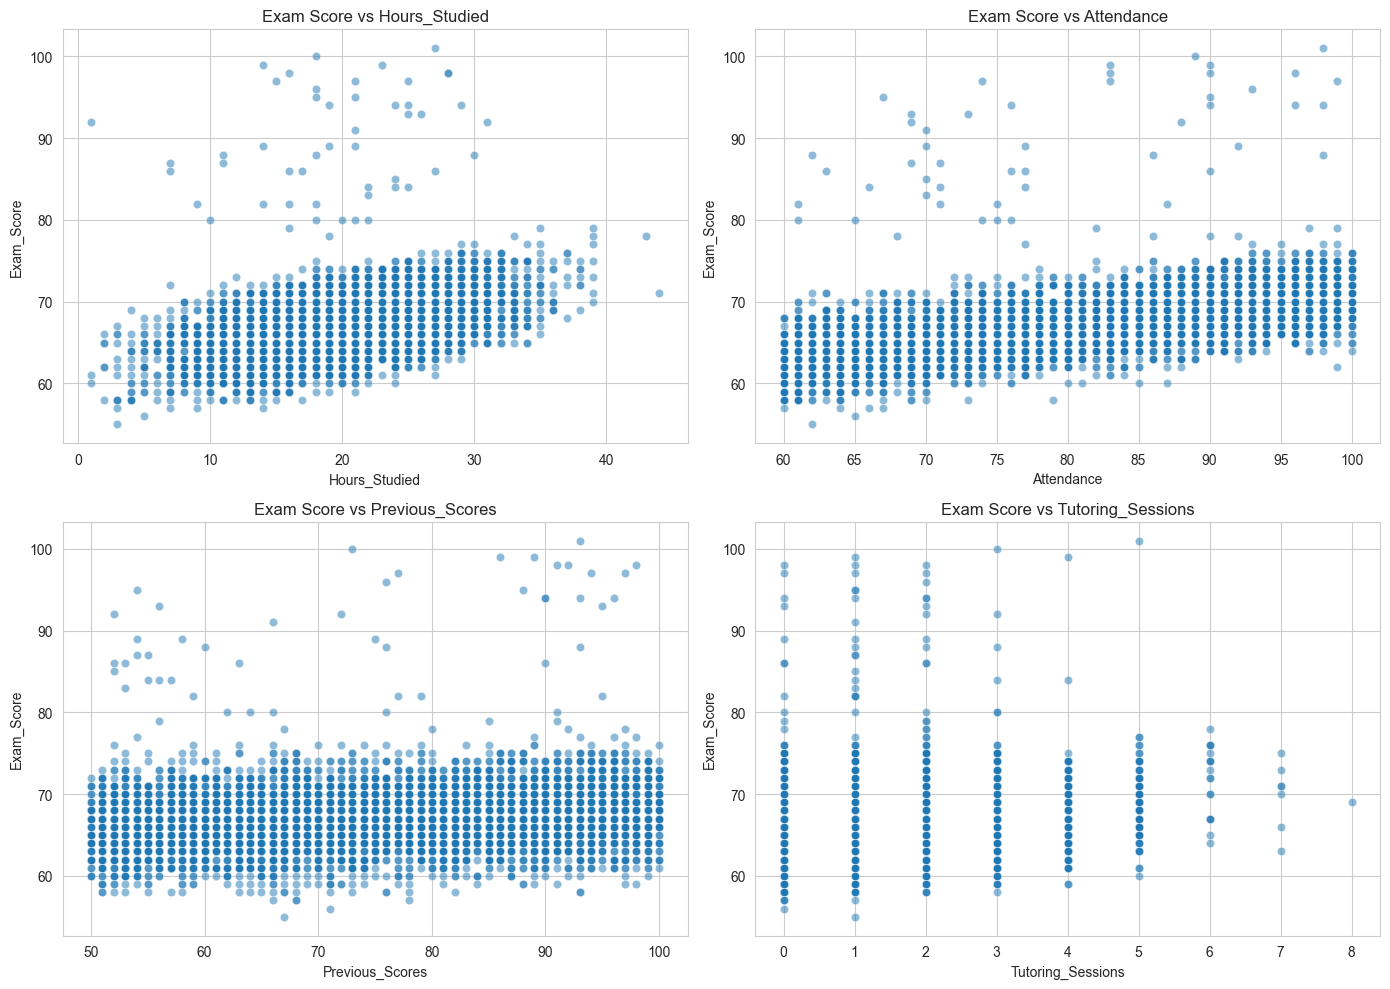

In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(academic_vars):
    sns.scatterplot(data=df, x=col, y="Exam_Score", ax=axes[i], alpha=0.5)
    axes[i].set_title(f"Exam Score vs {col}")

plt.tight_layout()
plt.show()

15. Encode Psychosocial Variables for Preliminary Correlation

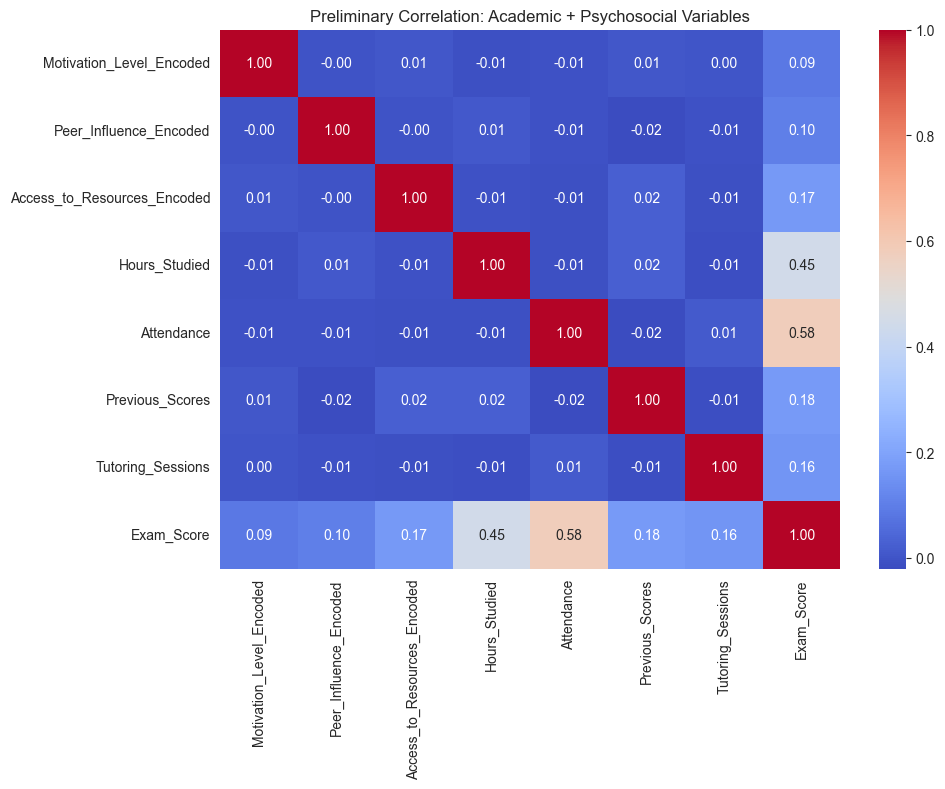

In [15]:
temp_df = df.copy()

motivation_map = {"Low": 1, "Medium": 2, "High": 3}
peer_map = {"Negative": 1, "Neutral": 2, "Positive": 3}
resource_map = {"Low": 1, "Medium": 2, "High": 3}

temp_df["Motivation_Level_Encoded"] = temp_df["Motivation_Level"].map(motivation_map)
temp_df["Peer_Influence_Encoded"] = temp_df["Peer_Influence"].map(peer_map)
temp_df["Access_to_Resources_Encoded"] = temp_df["Access_to_Resources"].map(resource_map)

prelim_corr_cols = [
    "Motivation_Level_Encoded",
    "Peer_Influence_Encoded",
    "Access_to_Resources_Encoded",
    "Hours_Studied",
    "Attendance",
    "Previous_Scores",
    "Tutoring_Sessions",
    "Exam_Score"
]

plt.figure(figsize=(10, 7))
sns.heatmap(temp_df[prelim_corr_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Preliminary Correlation: Academic + Psychosocial Variables")
plt.show()

16. Key EDA Summary Table

In [16]:
eda_summary = {
    "Variable": [],
    "Type": [],
    "Mean_Exam_Score_or_Correlation": []
}

# Psychosocial group means
for col in psychosocial_vars:
    group_means = df.groupby(col)["Exam_Score"].mean().to_dict()
    eda_summary["Variable"].append(col)
    eda_summary["Type"].append("Psychosocial Group Means")
    eda_summary["Mean_Exam_Score_or_Correlation"].append(group_means)

# Academic correlations
for col in academic_vars:
    corr_val = df[[col, "Exam_Score"]].corr().iloc[0, 1]
    eda_summary["Variable"].append(col)
    eda_summary["Type"].append("Academic Correlation")
    eda_summary["Mean_Exam_Score_or_Correlation"].append(round(corr_val, 4))

eda_summary_df = pd.DataFrame(eda_summary)
display(eda_summary_df)

,Variable,Type,Mean_Exam_Score_or_Correlation
0,Motivation_Level,Psychosocial Group Means,"{'High': 67.70432145564821, 'Low': 66.75219411..."
1,Peer_Influence,Psychosocial Group Means,"{'Negative': 66.56427015250544, 'Neutral': 67...."
2,Access_to_Resources,Psychosocial Group Means,"{'High': 68.09215189873417, 'Low': 66.20335110..."
3,Hours_Studied,Academic Correlation,0.4455
4,Attendance,Academic Correlation,0.5811
5,Previous_Scores,Academic Correlation,0.1751
6,Tutoring_Sessions,Academic Correlation,0.1565


17. Save Cleaned Dataset

In [17]:
output_file = "StudentPerformanceFactors_cleaned.csv"
df.to_csv(output_file, index=False)

print(f"Cleaned dataset saved as: {output_file}")

Cleaned dataset saved as: StudentPerformanceFactors_cleaned.csv


18. Final Observational Summary

In [18]:
print("=== NOTEBOOK 1 COMPLETE ===")
print("Saved cleaned dataset: StudentPerformanceFactors_cleaned.csv")
print("\nThis notebook established:")
print("- Dataset quality and structure")
print("- Target variable distribution")
print("- Psychosocial variable patterns")
print("- Academic variable relationships with Exam_Score")
print("- Clean dataset ready for feature engineering")

=== NOTEBOOK 1 COMPLETE ===
Saved cleaned dataset: StudentPerformanceFactors_cleaned.csv

This notebook established:
- Dataset quality and structure
- Target variable distribution
- Psychosocial variable patterns
- Academic variable relationships with Exam_Score
- Clean dataset ready for feature engineering
